In [18]:
#prepares the environment and decides whether computation will run on CPU 
import torch
from robustbench import load_model
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cpu


In [2]:
#load two RobustBench models
model_a = load_model(
    model_name="Standard",
    dataset="cifar10",
    threat_model="Linf"
).to(device)

model_b = load_model(
    model_name="Engstrom2019Robustness",
    dataset="cifar10",
    threat_model="Linf"
).to(device)

model_a.eval()
model_b.eval()

print(type(model_a))
print(type(model_b))

<class 'robustbench.model_zoo.architectures.wide_resnet.WideResNet'>
<class 'robustbench.model_zoo.cifar10.Engstrom2019RobustnessNet'>


In [3]:
#test that both models run correctly
x = torch.randn(1, 3, 32, 32).to(device)

with torch.no_grad():
    y_a = model_a(x)
    y_b = model_b(x)

print("Model A output shape:", y_a.shape)
print("Model B output shape:", y_b.shape)

Model A output shape: torch.Size([1, 10])
Model B output shape: torch.Size([1, 10])


In [4]:
#load real CIFAR-10 test data
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.ToTensor()

test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)
print("Test set loaded:", len(test_dataset))

Test set loaded: 10000


/Users/jesselemeer/anaconda3/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [5]:
images, labels = next(iter(test_loader))

images = images.to(device)
labels = labels.to(device)

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Labels:", labels)

Images shape: torch.Size([8, 3, 32, 32])
Labels shape: torch.Size([8])
Labels: tensor([3, 8, 8, 0, 6, 6, 1, 6])


In [6]:
#compare predictions of the two models
with torch.no_grad():
    out_a = model_a(images)
    out_b = model_b(images)

print("Model A output shape:", out_a.shape)
print("Model B output shape:", out_b.shape)


Model A output shape: torch.Size([8, 10])
Model B output shape: torch.Size([8, 10])


In [7]:
#compare predictions of the two models
pred_a = out_a.argmax(dim=1)
pred_b = out_b.argmax(dim=1)

print("True labels: ", labels.cpu().tolist())
print("Pred A:      ", pred_a.cpu().tolist())
print("Pred B:      ", pred_b.cpu().tolist())

True labels:  [3, 8, 8, 0, 6, 6, 1, 6]
Pred A:       [3, 8, 8, 0, 6, 6, 1, 6]
Pred B:       [3, 8, 8, 0, 6, 6, 1, 6]


In [8]:
#Count how many predictions each model got correct in this batch
correct_a = (pred_a == labels).sum().item()
correct_b = (pred_b == labels).sum().item()

print(f"Model A correct: {correct_a}/{labels.size(0)}")
print(f"Model B correct: {correct_b}/{labels.size(0)}")

Model A correct: 8/8
Model B correct: 8/8


In [9]:
#converts numeric class IDs into human-readable CIFAR-10 names
classes = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

for i in range(len(labels)):
    print(f"Image {i}: true={classes[labels[i].item()]}, "
          f"model_a={classes[pred_a[i].item()]}, "
          f"model_b={classes[pred_b[i].item()]}")

Image 0: true=cat, model_a=cat, model_b=cat
Image 1: true=ship, model_a=ship, model_b=ship
Image 2: true=ship, model_a=ship, model_b=ship
Image 3: true=airplane, model_a=airplane, model_b=airplane
Image 4: true=frog, model_a=frog, model_b=frog
Image 5: true=frog, model_a=frog, model_b=frog
Image 6: true=automobile, model_a=automobile, model_b=automobile
Image 7: true=frog, model_a=frog, model_b=frog


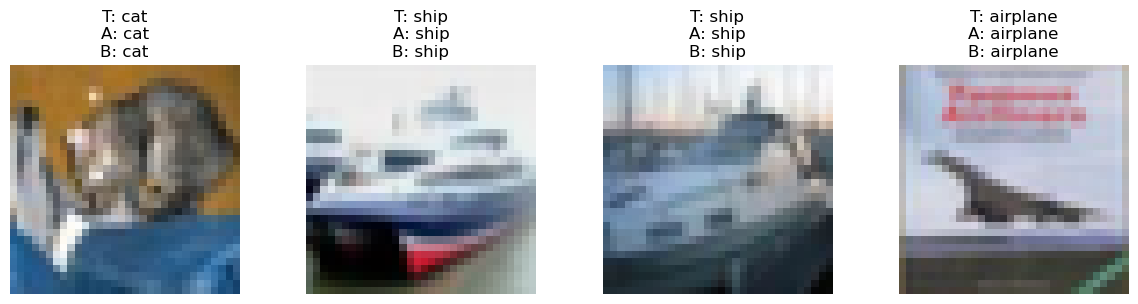

In [10]:
#Show a few images from the batch
import matplotlib.pyplot as plt

num_show = 4
fig, axes = plt.subplots(1, num_show, figsize=(12, 3))

for i in range(num_show):
    img = images[i].cpu().permute(1, 2, 0).numpy()
    axes[i].imshow(img)
    axes[i].set_title(
        f"T: {classes[labels[i].item()]}\n"
        f"A: {classes[pred_a[i].item()]}\n"
        f"B: {classes[pred_b[i].item()]}"
    )
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [11]:
#Measure clean accuracy on a few batches instead of just one
num_batches = 20
total = 0
correct_a = 0
correct_b = 0

with torch.no_grad():
    for batch_idx, (imgs, lbls) in enumerate(test_loader):
        if batch_idx >= num_batches:
            break

        imgs = imgs.to(device)
        lbls = lbls.to(device)

        out_a = model_a(imgs)
        out_b = model_b(imgs)

        pred_a = out_a.argmax(dim=1)
        pred_b = out_b.argmax(dim=1)

        correct_a += (pred_a == lbls).sum().item()
        correct_b += (pred_b == lbls).sum().item()
        total += lbls.size(0)

print(f"Model A clean accuracy on {total} images: {correct_a/total:.4f}")
print(f"Model B clean accuracy on {total} images: {correct_b/total:.4f}")

Model A clean accuracy on 160 images: 0.9437
Model B clean accuracy on 160 images: 0.9125


In [12]:
#Save one clean batch for later adversarial experiments
clean_images = images.clone().detach()
clean_labels = labels.clone().detach()

print("Saved clean batch:", clean_images.shape, clean_labels.shape)

Saved clean batch: torch.Size([8, 3, 32, 32]) torch.Size([8])


In [13]:
from autoattack import AutoAttack

attacker_a = AutoAttack(
    model_a,
    norm='Linf',
    eps=8/255,
    version='standard',
    device=device
)

print("AutoAttack ready")

setting parameters for standard version
AutoAttack ready


In [14]:
#Run AutoAttack on the clean batch for model_a
adv_images_a = attacker_a.run_standard_evaluation(
    clean_images,
    clean_labels,
    bs=8
)

using standard version including apgd-ce, apgd-t, fab-t, square.
initial accuracy: 100.00%
apgd-ce - 1/1 - 8 out of 8 successfully perturbed
robust accuracy after APGD-CE: 0.00% (total time 51.5 s)
max Linf perturbation: 0.03137, nan in tensor: 0, max: 1.00000, min: 0.00000
robust accuracy: 0.00%


In [15]:
#Evaluate model_a on the adversarial examples
with torch.no_grad():
    adv_out_a = model_a(adv_images_a)

adv_pred_a = adv_out_a.argmax(dim=1)

print("True labels: ", clean_labels.cpu().tolist())
print("Adv pred A:  ", adv_pred_a.cpu().tolist())

acc_a = (adv_pred_a == clean_labels).sum().item()
print(f"Model A accuracy on adversarial examples: {acc_a}/{clean_labels.size(0)}")

True labels:  [3, 8, 8, 0, 6, 6, 1, 6]
Adv pred A:   [6, 1, 2, 8, 3, 3, 5, 3]
Model A accuracy on adversarial examples: 0/8


In [ ]:
def compute_sat(model_a, model_b, images, labels, eps=8/255, device="cpu", eps_s=1e-6):
    #Find which examples are correctly classified by both models (X_AB)
    with torch.no_grad():
        pred_a = model_a(images).argmax(dim=1)
        pred_b = model_b(images).argmax(dim=1)

    correct_both = (pred_a == labels) & (pred_b == labels)
    X_AB = images[correct_both]
    y_AB = labels[correct_both]

    #Check for no overlap in correct predictions
    if len(X_AB) == 0:
        return float("nan") 

    #Generate adverserial examples for each model separately
    attacker_a = AutoAttack(model_a, norm="Linf", eps=eps, version="standard", device=device)
    x_A = attacker_a.run_standard_evaluation(X_AB, y_AB, bs=len(X_AB))

    attacker_b = AutoAttack(model_b, norm="Linf", eps=eps, version="standard", device=device)
    x_B = attacker_b.run_standard_evaluation(X_AB, y_AB, bs=len(X_AB))

    #Evaluate the adversarial examples of one model on the other model
    with torch.no_grad():
        transfer_B_to_A = (model_a(x_B).argmax(dim=1) != y_AB).float()
        transfer_A_to_B = (model_b(x_A).argmax(dim=1) != y_AB).float()

    #Calculate SAT score
    transfer_rate = (transfer_B_to_A + transfer_A_to_B).mean().item()*100/2
    sat_score = np.log(max(eps_s, transfer_rate))

    return sat_score

In [ ]:
#Use the clean batch saved earlier
sat_score = compute_sat(model_a, model_b, clean_images, clean_labels, device=device)
print(f"SAT(model_a, model_b) = {sat_score:.4f}")

setting parameters for standard version
using standard version including apgd-ce, apgd-t, fab-t, square.
initial accuracy: 100.00%
apgd-ce - 1/1 - 8 out of 8 successfully perturbed
robust accuracy after APGD-CE: 0.00% (total time 47.4 s)
max Linf perturbation: 0.03137, nan in tensor: 0, max: 1.00000, min: 0.00000
robust accuracy: 0.00%
setting parameters for standard version
using standard version including apgd-ce, apgd-t, fab-t, square.
initial accuracy: 100.00%
apgd-ce - 1/1 - 4 out of 8 successfully perturbed
robust accuracy after APGD-CE: 50.00% (total time 17.2 s)
apgd-t - 1/1 - 1 out of 4 successfully perturbed
robust accuracy after APGD-T: 37.50% (total time 89.8 s)
fab-t - 1/1 - 0 out of 3 successfully perturbed
robust accuracy after FAB-T: 37.50% (total time 232.2 s)
square - 1/1 - 0 out of 3 successfully perturbed
robust accuracy after SQUARE: 37.50% (total time 423.7 s)
max Linf perturbation: 0.03137, nan in tensor: 0, max: 1.00000, min: 0.00000
robust accuracy: 37.50%
SAT(